# Notebook 01: Data Ingestion & Exploratory Data Analysis

This notebook loads the synthetic clinical trial dataset, validates it, and performs comprehensive EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data_loader import load_data, validate_data, get_patient_summary

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Libraries loaded successfully.


## 1. Load and Validate Data

In [2]:
# Load the dataset
df = load_data('../data/clinical_trial_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
df.head(10)

Dataset shape: (6000, 9)

Column types:
patient_id                    object
trial_day                      int64
dosage_mg                      int64
compliance_pct               float64
adverse_event_flag             int64
doctor_notes                  object
outcome_score                float64
cohort                        object
visit_date            datetime64[ns]
dtype: object


,patient_id,trial_day,dosage_mg,compliance_pct,adverse_event_flag,doctor_notes,outcome_score,cohort,visit_date
0,P001,1,50,88.1,0,"Fatigue noted, monitoring ongoing.",79.84,A,2024-01-01
1,P001,2,50,84.8,0,"Patient stable, no complaints.",80.53,A,2024-01-02
2,P001,3,75,82.7,0,Symptoms improving with current dosage.,79.18,A,2024-01-03
3,P001,4,75,82.4,0,"Mild headache reported, advised rest.",88.83,A,2024-01-04
4,P001,5,50,81.3,0,"Patient stable, no complaints.",76.62,A,2024-01-05
5,P001,6,50,86.9,1,"Patient stable, no complaints.",66.06,A,2024-01-06
6,P001,7,100,89.6,0,"Patient stable, no complaints.",100.00,A,2024-01-07
7,P001,8,50,86.7,0,"Fatigue noted, monitoring ongoing.",77.67,A,2024-01-08
8,P001,9,75,90.2,0,Lab results within normal range.,79.16,A,2024-01-09
9,P001,10,100,79.4,1,"Mild headache reported, advised rest.",76.24,A,2024-01-10


In [3]:
# Validate the dataset
validation = validate_data(df)
for key, value in validation.items():
    print(f'{key}: {value}')

valid: True
num_rows: 6000
num_patients: 200
num_cohorts: 2
date_range: ('2024-01-01 00:00:00', '2024-01-30 00:00:00')
issues: []


## 2. Dataset Overview

In [4]:
# Descriptive statistics
df.describe().round(2)

,trial_day,dosage_mg,compliance_pct,adverse_event_flag,outcome_score,visit_date
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000
mean,15.50,75.25,88.22,0.11,85.41,2024-01-15 12:00:00
min,1.00,50.00,62.00,0.00,49.68,2024-01-01 00:00:00
25%,8.00,50.00,82.30,0.00,79.98,2024-01-08 00:00:00
50%,15.50,75.00,88.40,0.00,86.25,2024-01-15 12:00:00
75%,23.00,100.00,95.00,0.00,91.55,2024-01-23 00:00:00
max,30.00,100.00,100.00,1.00,100.00,2024-01-30 00:00:00
std,8.66,20.48,8.24,0.31,8.63,NaN


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
patient_id            0
trial_day             0
dosage_mg             0
compliance_pct        0
adverse_event_flag    0
doctor_notes          0
outcome_score         0
cohort                0
visit_date            0
dtype: int64

Total missing: 0


In [6]:
# Unique values summary
print(f'Unique patients: {df["patient_id"].nunique()}')
print(f'Cohorts: {df["cohort"].unique()}')
print(f'Dosage levels: {sorted(df["dosage_mg"].unique())}')
print(f'Date range: {df["visit_date"].min()} to {df["visit_date"].max()}')
print(f'\nDoctor notes categories: {df["doctor_notes"].nunique()}')

Unique patients: 200
Cohorts: ['A' 'B']
Dosage levels: [np.int64(50), np.int64(75), np.int64(100)]
Date range: 2024-01-01 00:00:00 to 2024-01-30 00:00:00

Doctor notes categories: 10


## 3. Distribution Analysis

/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T

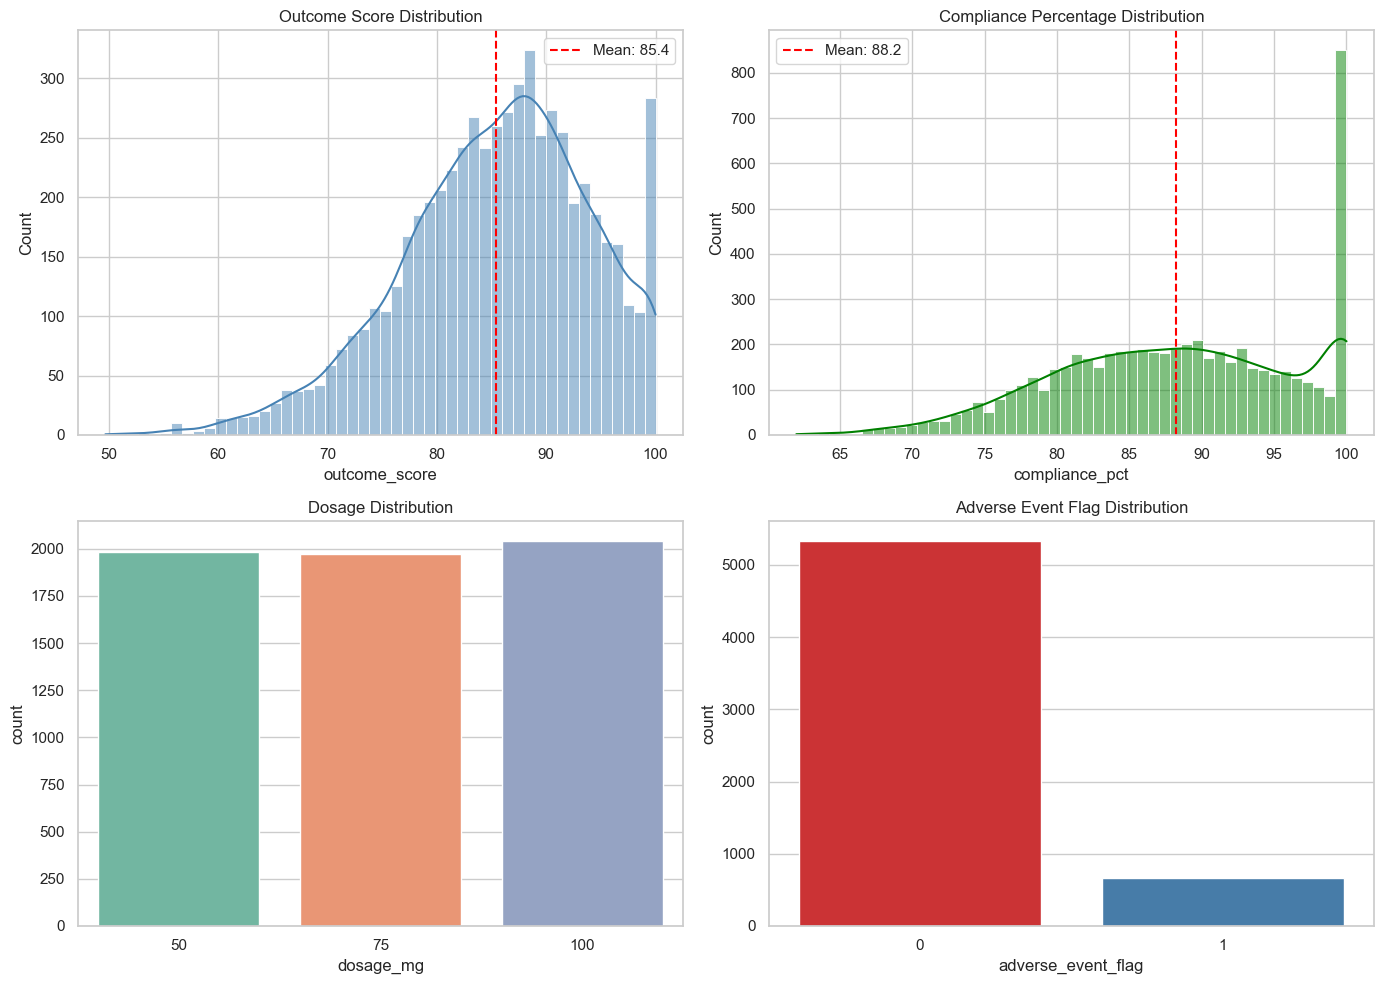

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Outcome score distribution
sns.histplot(df['outcome_score'], bins=50, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Outcome Score Distribution')
axes[0, 0].axvline(df['outcome_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["outcome_score"].mean():.1f}')
axes[0, 0].legend()

# Compliance distribution
sns.histplot(df['compliance_pct'], bins=50, kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Compliance Percentage Distribution')
axes[0, 1].axvline(df['compliance_pct'].mean(), color='red', linestyle='--', label=f'Mean: {df["compliance_pct"].mean():.1f}')
axes[0, 1].legend()

# Dosage distribution
sns.countplot(data=df, x='dosage_mg', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Dosage Distribution')

# Adverse event distribution
sns.countplot(data=df, x='adverse_event_flag', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Adverse Event Flag Distribution')

plt.tight_layout()
plt.show()

## 4. Cohort Analysis

/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_74922/196799083.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cohort', y='outcome_score', ax=axes[0], palette='Set2')
/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_74922/196799083.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cohort', y='compliance_pct', ax=axes[1], palette='Set2')


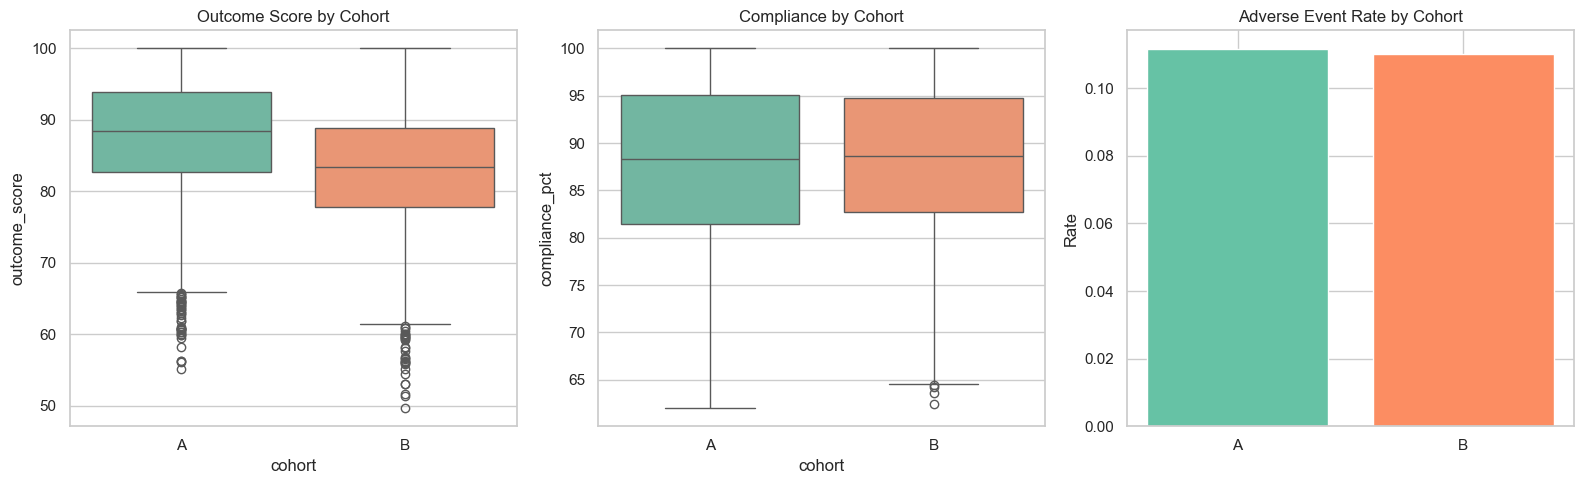

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Outcome by cohort
sns.boxplot(data=df, x='cohort', y='outcome_score', ax=axes[0], palette='Set2')
axes[0].set_title('Outcome Score by Cohort')

# Compliance by cohort
sns.boxplot(data=df, x='cohort', y='compliance_pct', ax=axes[1], palette='Set2')
axes[1].set_title('Compliance by Cohort')

# Adverse events by cohort
ae_rates = df.groupby('cohort')['adverse_event_flag'].mean()
axes[2].bar(ae_rates.index, ae_rates.values, color=['#66c2a5', '#fc8d62'])
axes[2].set_title('Adverse Event Rate by Cohort')
axes[2].set_ylabel('Rate')

plt.tight_layout()
plt.show()

## 5. Temporal Trends

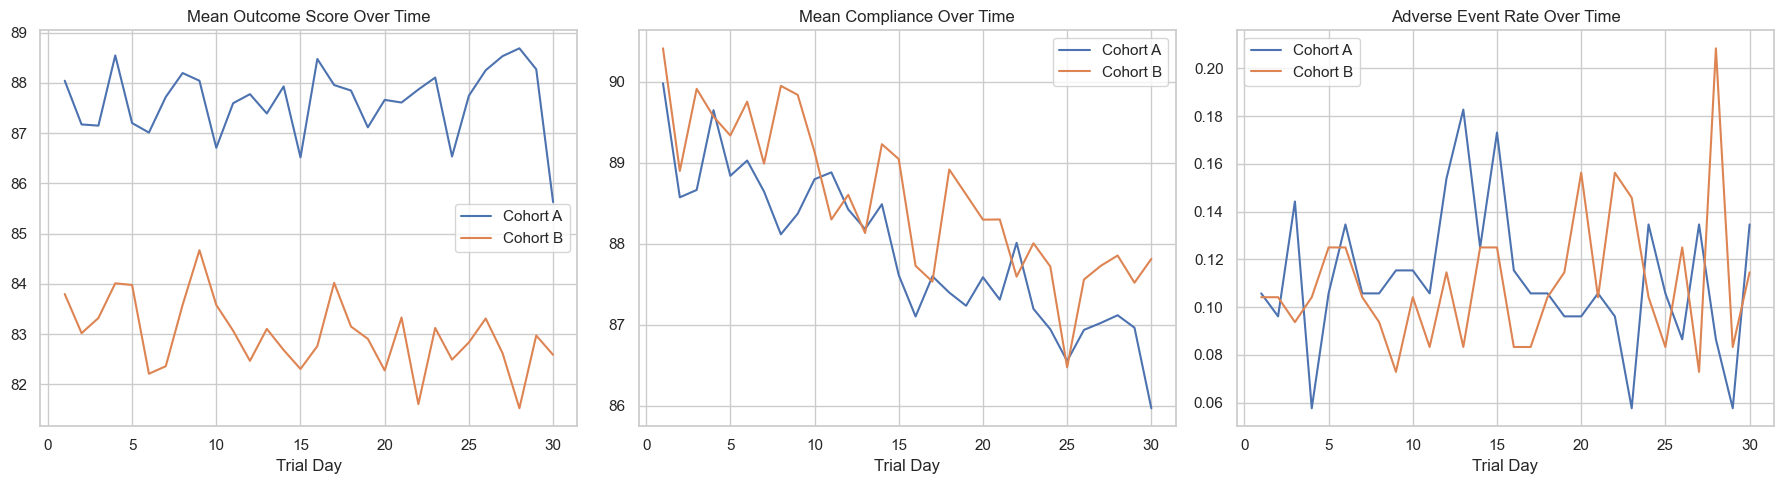

In [9]:
# Outcome trends over trial days
trends = df.groupby(['trial_day', 'cohort']).agg(
    mean_outcome=('outcome_score', 'mean'),
    mean_compliance=('compliance_pct', 'mean'),
    adverse_rate=('adverse_event_flag', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cohort in df['cohort'].unique():
    c_data = trends[trends['cohort'] == cohort]
    axes[0].plot(c_data['trial_day'], c_data['mean_outcome'], label=f'Cohort {cohort}')
    axes[1].plot(c_data['trial_day'], c_data['mean_compliance'], label=f'Cohort {cohort}')
    axes[2].plot(c_data['trial_day'], c_data['adverse_rate'], label=f'Cohort {cohort}')

axes[0].set_title('Mean Outcome Score Over Time')
axes[0].set_xlabel('Trial Day')
axes[0].legend()

axes[1].set_title('Mean Compliance Over Time')
axes[1].set_xlabel('Trial Day')
axes[1].legend()

axes[2].set_title('Adverse Event Rate Over Time')
axes[2].set_xlabel('Trial Day')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

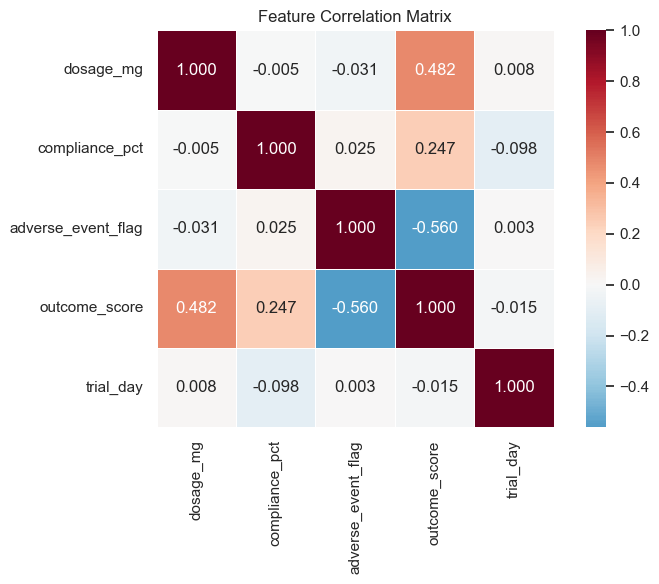

In [10]:
# Correlation heatmap
numeric_cols = ['dosage_mg', 'compliance_pct', 'adverse_event_flag', 'outcome_score', 'trial_day']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Doctor Notes Analysis

/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_74922/2656338927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=notes_freq.values, y=notes_freq.index, palette='viridis')


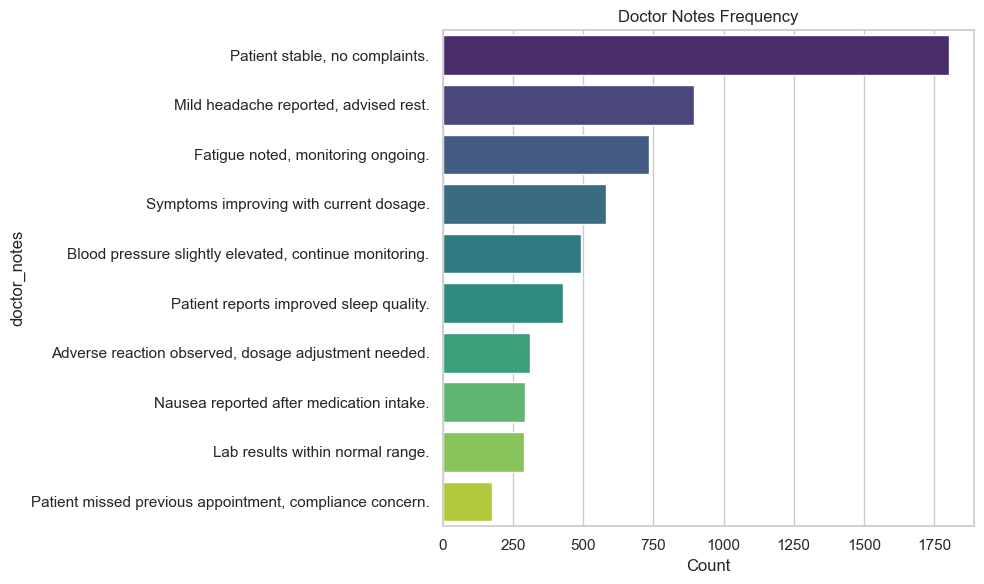


Doctor Notes vs Adverse Event Rate:
  13.35% - Fatigue noted, monitoring ongoing.
  12.01% - Symptoms improving with current dosage.
  12.00% - Patient missed previous appointment, compliance concern.
  11.49% - Patient stable, no complaints.
  10.73% - Mild headache reported, advised rest.
  10.57% - Blood pressure slightly elevated, continue monitoring.
  9.71% - Adverse reaction observed, dosage adjustment needed.
  9.58% - Patient reports improved sleep quality.
  8.65% - Lab results within normal range.
  8.53% - Nausea reported after medication intake.


In [11]:
# Doctor notes frequency
notes_freq = df['doctor_notes'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=notes_freq.values, y=notes_freq.index, palette='viridis')
plt.title('Doctor Notes Frequency')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Cross-tab: notes vs adverse events
print('\nDoctor Notes vs Adverse Event Rate:')
crosstab = df.groupby('doctor_notes')['adverse_event_flag'].mean().sort_values(ascending=False)
for note, rate in crosstab.items():
    print(f'  {rate:.2%} - {note}')

## 8. Patient-Level Summary (Sample)

In [12]:
# Sample patient summary
for pid in ['P001', 'P050', 'P100']:
    summary = get_patient_summary(df, pid)
    print(f'\n--- Patient {pid} ---')
    for k, v in summary.items():
        print(f'  {k}: {v}')


--- Patient P001 ---
  patient_id: P001
  cohort: A
  num_visits: 30
  avg_compliance: 84.0
  avg_outcome: 82.05
  total_adverse_events: 4
  dosages_used: [50, 75, 100]
  date_range: ('2024-01-01 00:00:00', '2024-01-30 00:00:00')

--- Patient P050 ---
  patient_id: P050
  cohort: A
  num_visits: 30
  avg_compliance: 97.2
  avg_outcome: 89.65
  total_adverse_events: 4
  dosages_used: [50, 75, 100]
  date_range: ('2024-01-01 00:00:00', '2024-01-30 00:00:00')

--- Patient P100 ---
  patient_id: P100
  cohort: A
  num_visits: 30
  avg_compliance: 86.5
  avg_outcome: 88.55
  total_adverse_events: 2
  dosages_used: [50, 75, 100]
  date_range: ('2024-01-01 00:00:00', '2024-01-30 00:00:00')


## Key Takeaways

- Dataset contains 6,000 records across 200 patients in 2 cohorts over 30 trial days
- Outcome scores are roughly normally distributed with a mean around 80
- Compliance shows slight decline over the trial period
- ~10% adverse event rate, consistent across cohorts
- Positive correlation between compliance and outcome scores
- Doctor notes provide qualitative signal aligned with quantitative metrics